# CineMatch — Full EDA
**Letterboxd × TMDb** | Tiers · Popularity Bias · Director/Actor Impact · Recommender Patterns

In [1]:
import subprocess, sys
for pkg in ["pandas","numpy","matplotlib","seaborn","scipy","scikit-learn","tqdm"]:
    try: __import__(pkg.replace("-","_"))
    except ImportError: subprocess.check_call([sys.executable,"-m","pip","install","-q",pkg])
print("deps OK")

deps OK



[notice] A new release of pip is available: 24.3.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import warnings, re
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.facecolor": "#0d0d0d",
    "figure.facecolor": "#0d0d0d",
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "axes.edgecolor": "#444",
    "grid.color": "#2a2a2a",
    "axes.titlecolor": "white",
    "axes.grid": True,
})
GOLD   = "#E8A838"
TEAL   = "#2E8B82"
CREAM  = "#F0E6D0"
MUTED  = "#7A7060"
PAL    = [GOLD, TEAL, "#C0392B", "#8E44AD", CREAM]

REPO   = Path("/Users/nandana/data-trio-project")
print("Imports OK")

Imports OK


## 1  Load & Merge Data

In [3]:
# ── Letterboxd (22 splits) ────────────────────────────────────────────────────
lbx_frames = []
for n in range(1, 23):
    p = Path(f"letterboxd_split_{n}.csv")
    if p.exists():
        lbx_frames.append(pd.read_csv(p))
    else:
        print(f"  [skip] {p.name}")

lbx = pd.concat(lbx_frames, ignore_index=True)
print(f"Letterboxd  {lbx.shape[0]:,} rows  {lbx['username'].nunique():,} users  {lbx['movie_title'].nunique():,} films")
lbx.head(2)

Letterboxd  10,669,089 rows  3,840 users  300,137 films


,username,tmdb_id,movie_title,rating,genre,subgenre_1,subgenre_2,subgenre_3,subgenre_4,subgenre_5,num_ratings,avg_rating,director_url,actors_url
0,schaffrillas,1226863.0,The Super Mario Galaxy Movie,2.5,Family,Comedy,Adventure,Fantasy,Animation,NaN,NaN,NaN,/director/aaron-horvath/,"/actor/chris-pratt/,/actor/charlie-day/,/actor..."
1,schaffrillas,1493859.0,Pizza Movie,3.5,Comedy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,/director/victoria-vincent/,NaN


In [4]:
# ── TMDb (2 parts) ────────────────────────────────────────────────────────────
tmdb_frames = []
for n in range(1, 3):
    p = Path(f"movie_data_part{n}.csv")
    if p.exists():
        tmdb_frames.append(pd.read_csv(p))
    else:
        print(f"  [skip] {p.name}")

tmdb = pd.concat(tmdb_frames, ignore_index=True).drop_duplicates(subset="tmdb_id")
print(f"TMDb  {tmdb.shape[0]:,} films  {tmdb.columns.tolist()[:10]} ...")
tmdb.head(2)

TMDb  285,459 films  ['movie_id', 'release_decade', 'production_companies', 'production_countries', 'revenue_x', 'profit_x', 'movie_age', 'release_date', 'budget_x', 'name'] ...


,movie_id,release_decade,production_companies,production_countries,revenue_x,profit_x,movie_age,release_date,budget_x,name,...,kw_remake,kw_based_on_true_story,kw_sequel,kw_based_on_novel,kw_documentary,kw_direct-to-video,star_power,budget_per_min,profit_y,profit_margin
0,1,2020.0,"[{'name': 'Illumination', 'id': 6704}, {'name'...","['japan', 'united states of america']",894200000.0,784200000.0,0.0,2026-04-01,110000000.0,The Super Mario Galaxy Movie,...,False,False,True,False,False,False,5.8011,1122448.98,784200000.0,7.1291
1,2,2020.0,"[{'name': 'American High', 'id': 112397}, {'na...",['united states of america'],NaN,NaN,0.0,2026-03-13,NaN,Pizza Movie,...,False,False,False,False,False,False,2.3451,NaN,NaN,NaN


In [5]:
# ── Merge on tmdb_id ─────────────────────────────────────────────────────────
TMDB_KEEP = [
    "tmdb_id","name","release_type","release_year_x","release_month",
    "budget_x","revenue_x","profit_x","profit_margin",
    "runtime_x","original_language_x","production_country_group",
    "is_major_studio","is_us_production","in_franchise_x",
    "director_name","director_popularity","director_prior_films",
    "cast_1_popularity","cast_2_popularity","cast_3_popularity","star_power",
    "cast_size","vote_average","vote_count","popularity",
    "kw_independent_film","kw_animation","kw_superhero","kw_remake",
    "kw_based_on_true_story","kw_sequel","kw_based_on_novel",
    "kw_documentary","kw_direct-to-video","release_decade",
    "social_media_count","belongs_to_collection",
]
tmdb_slim = tmdb[[c for c in TMDB_KEEP if c in tmdb.columns]].copy()

df = lbx.merge(tmdb_slim, on="tmdb_id", how="left")
print(f"Merged  {df.shape[0]:,} rows  {df.shape[1]} columns")
print(f"TMDb match rate: {df['director_name'].notna().mean():.1%}")
df.head(2)

Merged  10,669,089 rows  51 columns
TMDb match rate: 90.4%


,username,tmdb_id,movie_title,rating,genre,subgenre_1,subgenre_2,subgenre_3,subgenre_4,subgenre_5,...,kw_superhero,kw_remake,kw_based_on_true_story,kw_sequel,kw_based_on_novel,kw_documentary,kw_direct-to-video,release_decade,social_media_count,belongs_to_collection
0,schaffrillas,1226863.0,The Super Mario Galaxy Movie,2.5,Family,Comedy,Adventure,Fantasy,Animation,NaN,...,False,False,False,True,False,False,False,2020.0,3.0,"{'name': 'The Super Mario Collection', 'id': 1..."
1,schaffrillas,1493859.0,Pizza Movie,3.5,Comedy,NaN,NaN,NaN,NaN,NaN,...,False,False,False,False,False,False,False,2020.0,0.0,NaN


## 2  Clean & Tier Films

In [6]:
# ── Basic cleaning ────────────────────────────────────────────────────────────
df["rating"]      = pd.to_numeric(df["rating"],      errors="coerce")
df["avg_rating"]  = pd.to_numeric(df["avg_rating"],  errors="coerce")
df["num_ratings"] = pd.to_numeric(df["num_ratings"], errors="coerce")
df["budget_x"]    = pd.to_numeric(df["budget_x"],    errors="coerce")
df["revenue_x"]   = pd.to_numeric(df["revenue_x"],   errors="coerce")
df["profit_x"]    = pd.to_numeric(df["profit_x"],    errors="coerce")

# strip /director/ and /actor/ slugs to readable names
def slug_to_name(s):
    if pd.isna(s): return None
    return s.strip("/").split("/")[-1].replace("-", " ").title()

df["director_slug"] = df["director_url"].apply(slug_to_name)

# ── Film-level aggregate (one row per unique film) ────────────────────────────
film_cols = [
    "tmdb_id","movie_title","genre","subgenre_1","subgenre_2",
    "num_ratings","avg_rating",
    "director_slug","director_popularity","director_prior_films",
    "cast_1_popularity","cast_2_popularity","cast_3_popularity","star_power",
    "budget_x","revenue_x","profit_x","profit_margin",
    "runtime_x","release_type","release_year_x","release_month",
    "is_major_studio","is_us_production","in_franchise_x",
    "vote_average","vote_count","popularity","release_decade",
    "kw_independent_film","kw_animation","kw_superhero","kw_sequel",
    "kw_based_on_true_story","kw_documentary","kw_direct-to-video",
    "social_media_count","belongs_to_collection",
]
film_cols = [c for c in film_cols if c in df.columns]
films = df[film_cols].drop_duplicates(subset="tmdb_id").copy()
print(f"Film-level table: {len(films):,} unique films")

Film-level table: 336,764 unique films


In [7]:
# ── Tier by num_ratings + avg_rating composite score ─────────────────────────
# Normalise both 0-1 then average → tier_score
films["nr_norm"]  = (films["num_ratings"] - films["num_ratings"].min()) / (films["num_ratings"].max() - films["num_ratings"].min())
films["avg_norm"] = (films["avg_rating"]  - films["avg_rating"].min())  / (films["avg_rating"].max()  - films["avg_rating"].min())
films["tier_score"] = (films["nr_norm"] + films["avg_norm"]) / 2

q33, q66 = films["tier_score"].quantile([0.33, 0.66])
def assign_tier(s):
    if s >= q66:  return "High"
    if s >= q33:  return "Mid"
    return "Low"

films["tier"] = films["tier_score"].apply(assign_tier)
df = df.merge(films[["tmdb_id","tier","tier_score"]], on="tmdb_id", how="left")

print(films["tier"].value_counts())
print("\nTier score stats:")
print(films.groupby("tier")[["num_ratings","avg_rating"]].mean().round(2))

tier
Low     258150
High     39900
Mid      38714
Name: count, dtype: int64

Tier score stats:
      num_ratings  avg_rating
tier                         
High     34570.89        3.67
Low       7600.12        2.77
Mid       5520.55        3.28


## 3  What Makes High-Tier Films High-Tier?

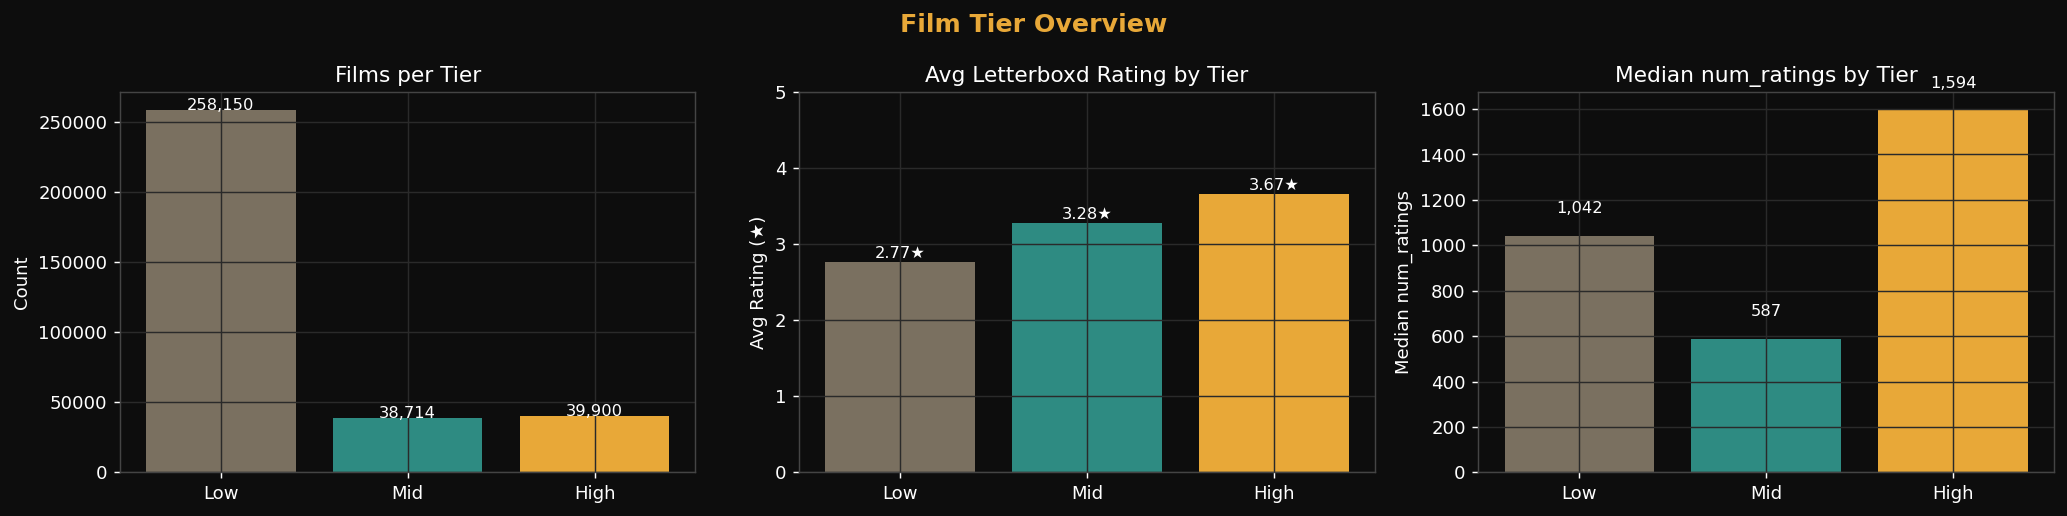

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Film Tier Overview", color=GOLD, fontsize=14, fontweight="bold")

order = ["Low","Mid","High"]
colors = [MUTED, TEAL, GOLD]

# Count
counts = films["tier"].value_counts().reindex(order)
axes[0].bar(order, counts, color=colors)
axes[0].set_title("Films per Tier")
axes[0].set_ylabel("Count")
for i,(o,c) in enumerate(zip(order, counts)):
    axes[0].text(i, c+50, f"{c:,}", ha="center", color="white", fontsize=9)

# Avg rating by tier
means = films.groupby("tier")["avg_rating"].mean().reindex(order)
axes[1].bar(order, means, color=colors)
axes[1].set_title("Avg Letterboxd Rating by Tier")
axes[1].set_ylabel("Avg Rating (★)")
axes[1].set_ylim(0, 5)
for i,(o,m) in enumerate(zip(order,means)):
    axes[1].text(i, m+0.05, f"{m:.2f}★", ha="center", color="white", fontsize=9)

# Num ratings by tier
medians = films.groupby("tier")["num_ratings"].median().reindex(order)
axes[2].bar(order, medians, color=colors)
axes[2].set_title("Median num_ratings by Tier")
axes[2].set_ylabel("Median num_ratings")
for i,(o,m) in enumerate(zip(order,medians)):
    axes[2].text(i, m+100, f"{int(m):,}", ha="center", color="white", fontsize=9)

plt.tight_layout()
plt.savefig("tier_overview.png", bbox_inches="tight", facecolor="#0d0d0d")
plt.show()

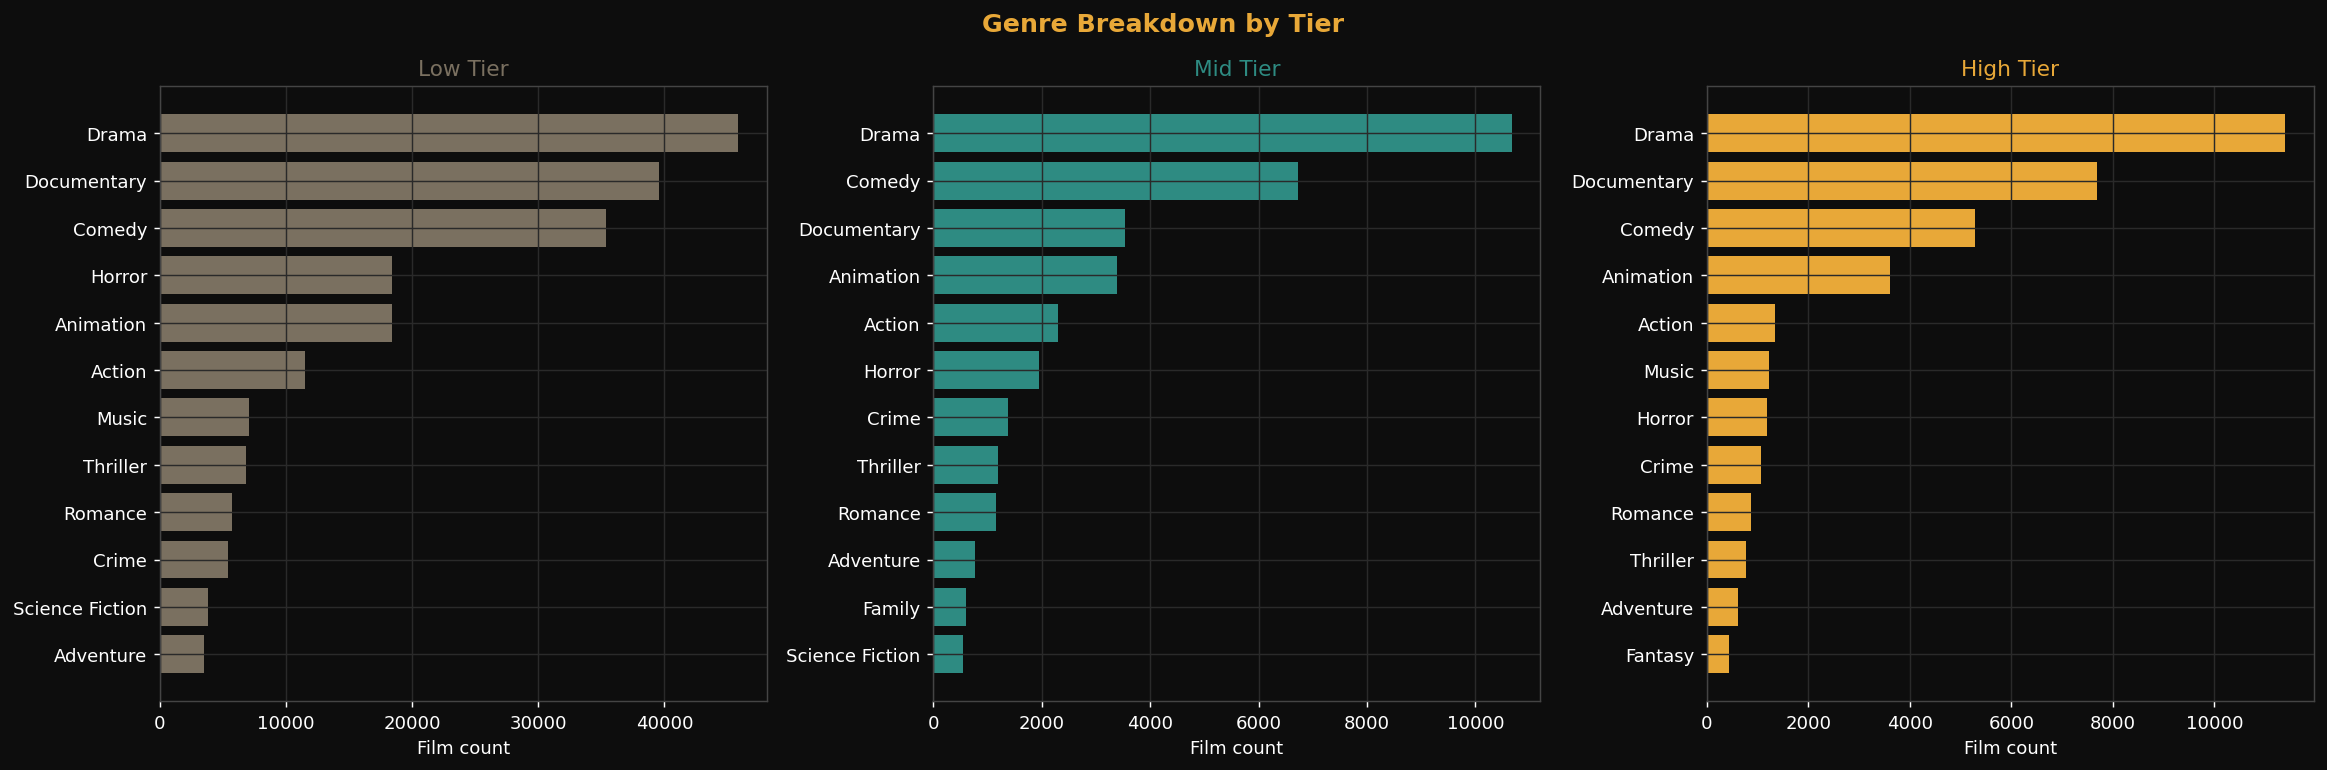

In [9]:
# Genre composition per tier
genre_tier = (
    films.groupby(["tier","genre"]).size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Genre Breakdown by Tier", color=GOLD, fontsize=14, fontweight="bold")
for ax, (tier, color) in zip(axes, zip(["Low","Mid","High"], [MUTED, TEAL, GOLD])):
    sub = genre_tier[genre_tier["tier"]==tier].head(12)
    ax.barh(sub["genre"][::-1], sub["count"][::-1], color=color)
    ax.set_title(f"{tier} Tier", color=color)
    ax.set_xlabel("Film count")
plt.tight_layout()
plt.savefig("genre_by_tier.png", bbox_inches="tight", facecolor="#0d0d0d")
plt.show()

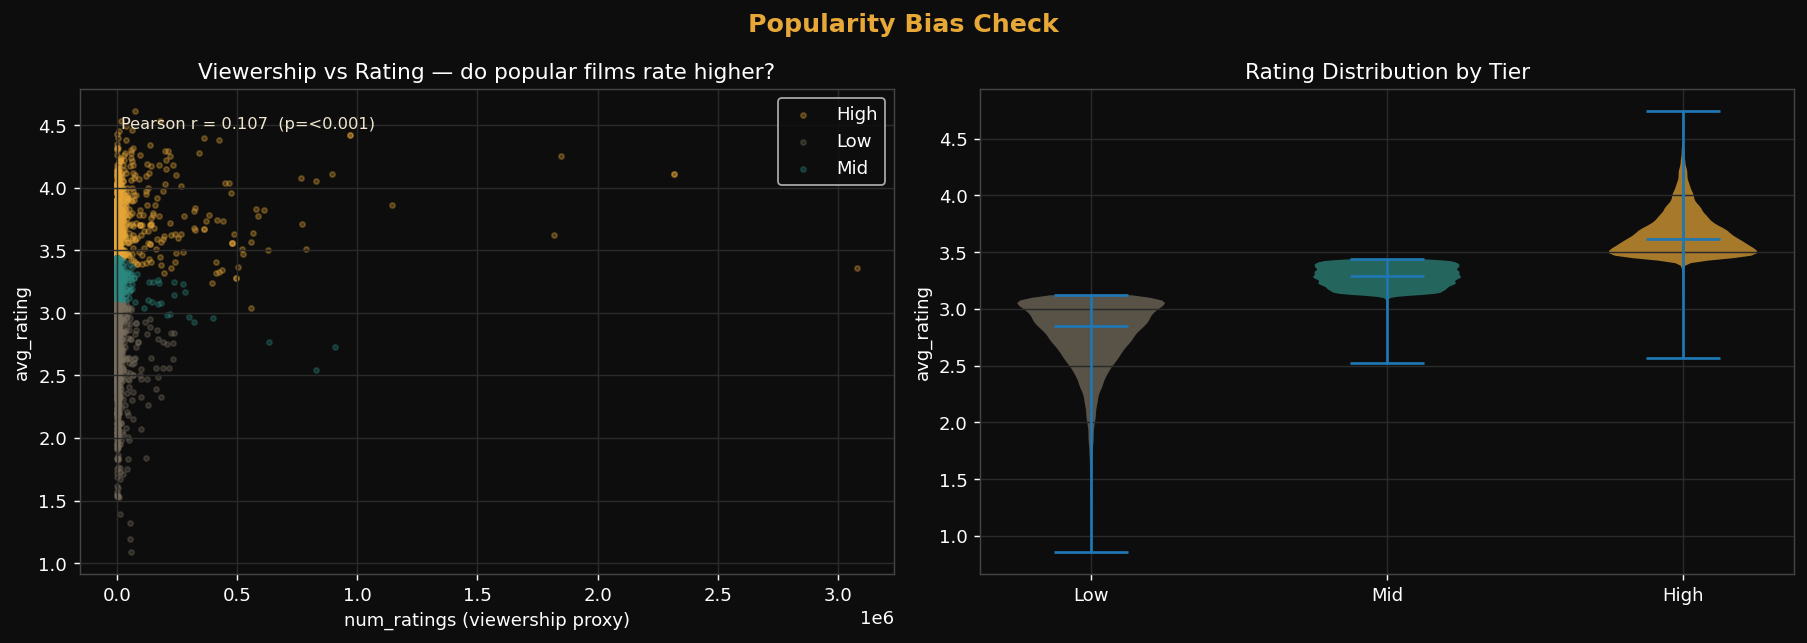

Pearson r (num_ratings vs avg_rating): 0.107


In [10]:
# Popularity bias: does high viewership → inflated avg_rating?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Popularity Bias Check", color=GOLD, fontsize=14, fontweight="bold")

# Scatter: num_ratings vs avg_rating
sample = films.dropna(subset=["num_ratings","avg_rating"]).sample(min(5000, len(films)), random_state=42)
tier_color_map = {"Low": MUTED, "Mid": TEAL, "High": GOLD}
for tier, grp in sample.groupby("tier"):
    axes[0].scatter(grp["num_ratings"], grp["avg_rating"],
                    alpha=0.3, s=8, color=tier_color_map[tier], label=tier)
axes[0].set_xlabel("num_ratings (viewership proxy)")
axes[0].set_ylabel("avg_rating")
axes[0].set_title("Viewership vs Rating — do popular films rate higher?")
axes[0].legend()

# Pearson r annotation
r, p = stats.pearsonr(
    sample["num_ratings"].fillna(0),
    sample["avg_rating"].fillna(0)
)
axes[0].text(0.05, 0.92, f"Pearson r = {r:.3f}  (p={'<0.001' if p<0.001 else f'{p:.3f}'})",
             transform=axes[0].transAxes, color=CREAM, fontsize=9)

# Rating distribution by tier — violin
tier_data = [films[films["tier"]==t]["avg_rating"].dropna() for t in ["Low","Mid","High"]]
vp = axes[1].violinplot(tier_data, positions=[0,1,2], showmedians=True)
for i,(body,color) in enumerate(zip(vp["bodies"],[MUTED,TEAL,GOLD])):
    body.set_facecolor(color); body.set_alpha(0.7)
axes[1].set_xticks([0,1,2]); axes[1].set_xticklabels(["Low","Mid","High"])
axes[1].set_title("Rating Distribution by Tier")
axes[1].set_ylabel("avg_rating")

plt.tight_layout()
plt.savefig("popularity_bias.png", bbox_inches="tight", facecolor="#0d0d0d")
plt.show()
print(f"Pearson r (num_ratings vs avg_rating): {r:.3f}")

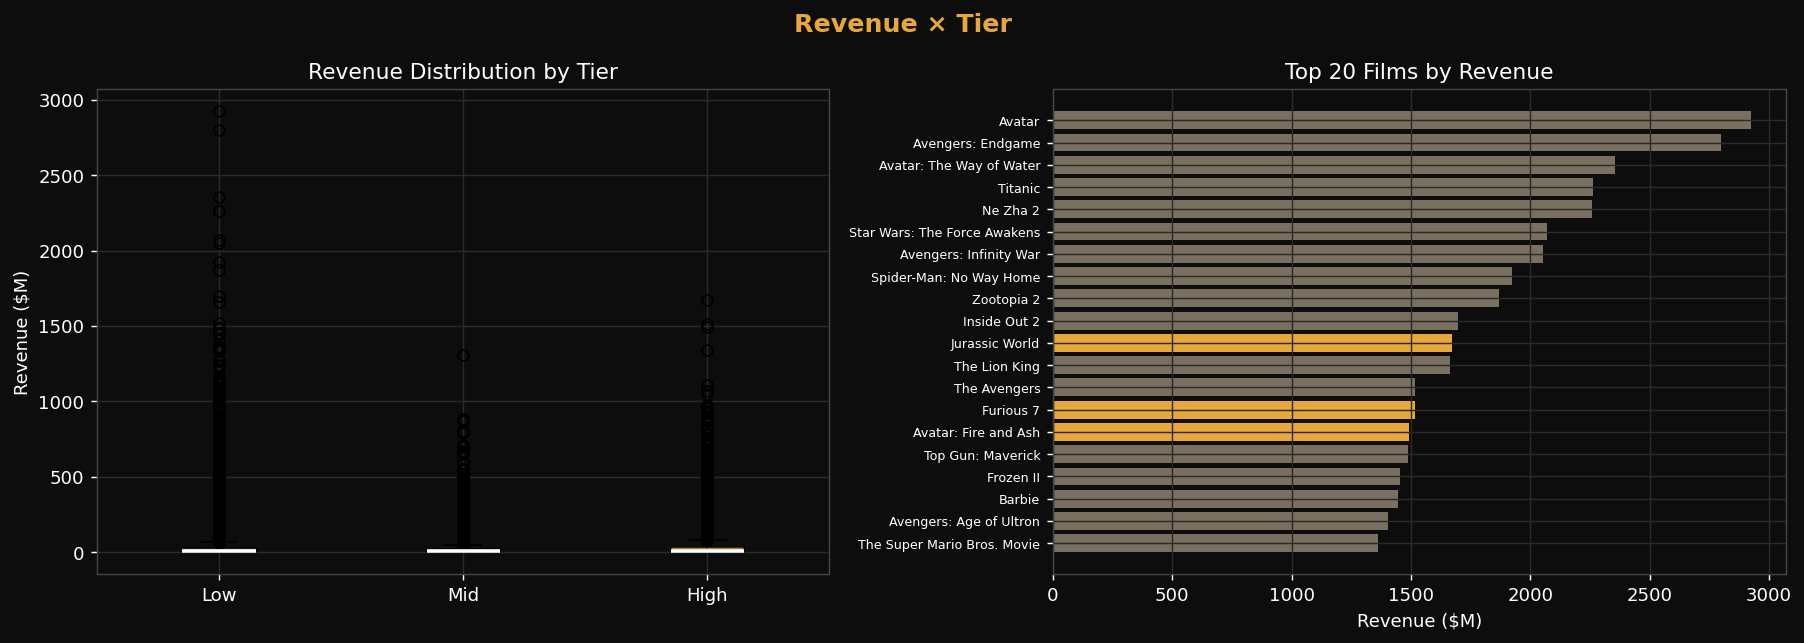

In [11]:
# Revenue: do high-tier films make more money?
rev = films.dropna(subset=["revenue_x","tier"]).copy()
rev["revenue_m"] = rev["revenue_x"] / 1e6

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Revenue × Tier", color=GOLD, fontsize=14, fontweight="bold")

# Box plot
rev_data = [rev[rev["tier"]==t]["revenue_m"] for t in ["Low","Mid","High"]]
bp = axes[0].boxplot(rev_data, labels=["Low","Mid","High"], patch_artist=True,
                     medianprops=dict(color="white",linewidth=2))
for patch, color in zip(bp["boxes"],[MUTED,TEAL,GOLD]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[0].set_ylabel("Revenue ($M)")
axes[0].set_title("Revenue Distribution by Tier")

# Top 20 highest revenue films coloured by tier
top_rev = rev.nlargest(20,"revenue_x")
colors_top = [tier_color_map[t] for t in top_rev["tier"]]
axes[1].barh(top_rev["movie_title"][::-1], top_rev["revenue_m"][::-1], color=colors_top[::-1])
axes[1].set_xlabel("Revenue ($M)")
axes[1].set_title("Top 20 Films by Revenue")
axes[1].tick_params(axis="y", labelsize=7)

plt.tight_layout()
plt.savefig("revenue_tier.png", bbox_inches="tight", facecolor="#0d0d0d")
plt.show()

In [17]:
print(films.columns.tolist())

['tmdb_id', 'movie_title', 'genre', 'subgenre_1', 'subgenre_2', 'num_ratings', 'avg_rating', 'director_slug', 'director_popularity', 'director_prior_films', 'cast_1_popularity', 'cast_2_popularity', 'cast_3_popularity', 'star_power', 'budget_x', 'revenue_x', 'profit_x', 'profit_margin', 'runtime_x', 'release_type', 'release_year_x', 'release_month', 'is_major_studio', 'is_us_production', 'in_franchise_x', 'vote_average', 'vote_count', 'popularity', 'release_decade', 'kw_independent_film', 'kw_animation', 'kw_superhero', 'kw_sequel', 'kw_based_on_true_story', 'kw_documentary', 'kw_direct-to-video', 'social_media_count', 'belongs_to_collection', 'nr_norm', 'avg_norm', 'tier_score', 'tier']


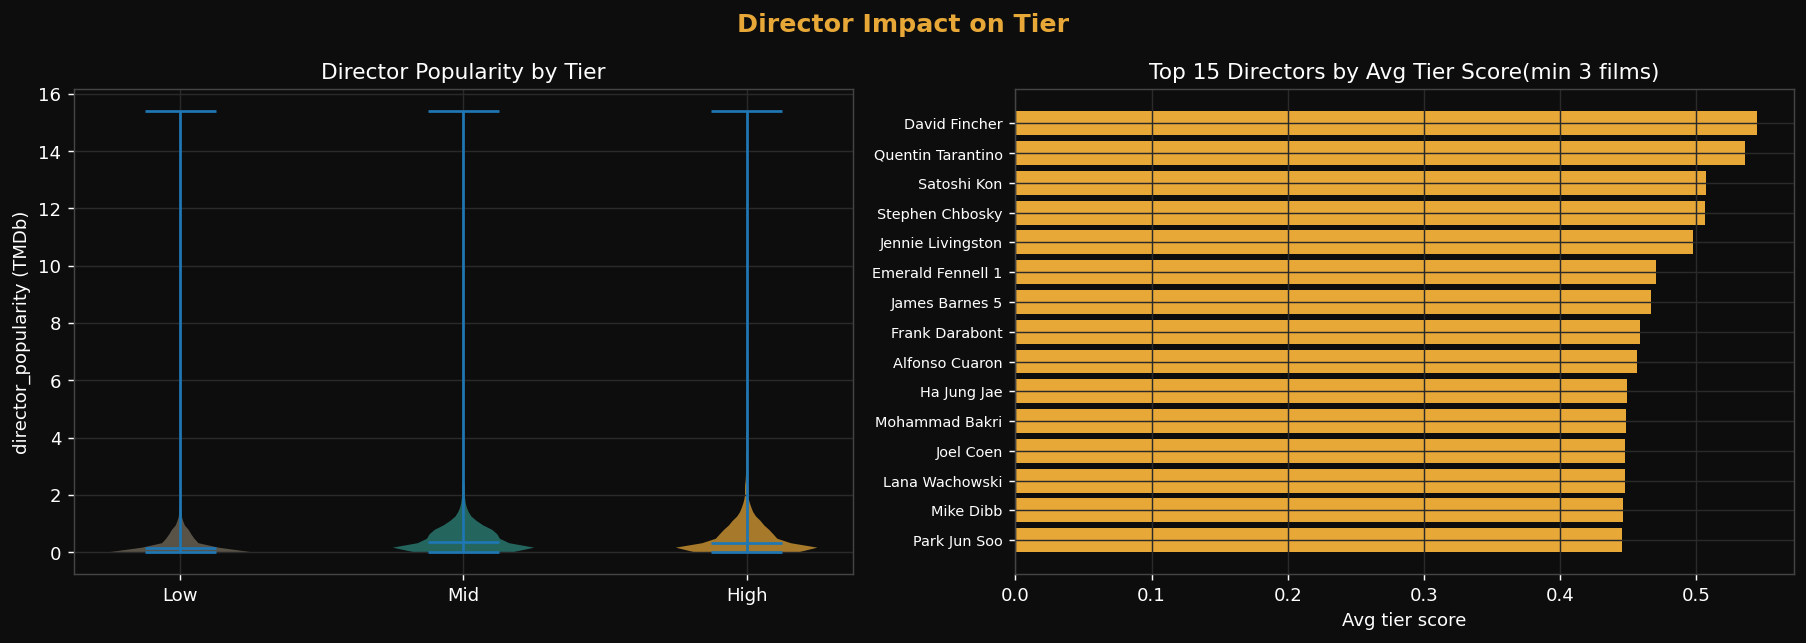

In [21]:
# Director popularity vs film tier
dir_df = films.dropna(subset=["director_popularity","director_slug","tier"]).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Director Impact on Tier", color=GOLD, fontsize=14, fontweight="bold")

# Director popularity by tier
dp_data = [dir_df[dir_df["tier"]==t]["director_popularity"] for t in ["Low","Mid","High"]]
vp = axes[0].violinplot(dp_data, positions=[0,1,2], showmedians=True)
for body, color in zip(vp["bodies"],[MUTED,TEAL,GOLD]):
    body.set_facecolor(color); body.set_alpha(0.7)
axes[0].set_xticks([0,1,2]); axes[0].set_xticklabels(["Low","Mid","High"])
axes[0].set_title("Director Popularity by Tier")
axes[0].set_ylabel("director_popularity (TMDb)")

# Top 15 directors by avg film tier score
top_dirs = (
    dir_df.groupby("director_slug")
    .agg(avg_tier_score=("tier_score","mean"), film_count=("tmdb_id","nunique"))
    .query("film_count >= 3")
    .nlargest(15,"avg_tier_score")
    .reset_index()
)
axes[1].barh(top_dirs["director_slug"][::-1], top_dirs["avg_tier_score"][::-1], color=GOLD)
axes[1].set_xlabel("Avg tier score")
axes[1].set_title("Top 15 Directors by Avg Tier Score(min 3 films)")

axes[1].tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.savefig("director_impact.png", bbox_inches="tight", facecolor="#0d0d0d")
plt.show()

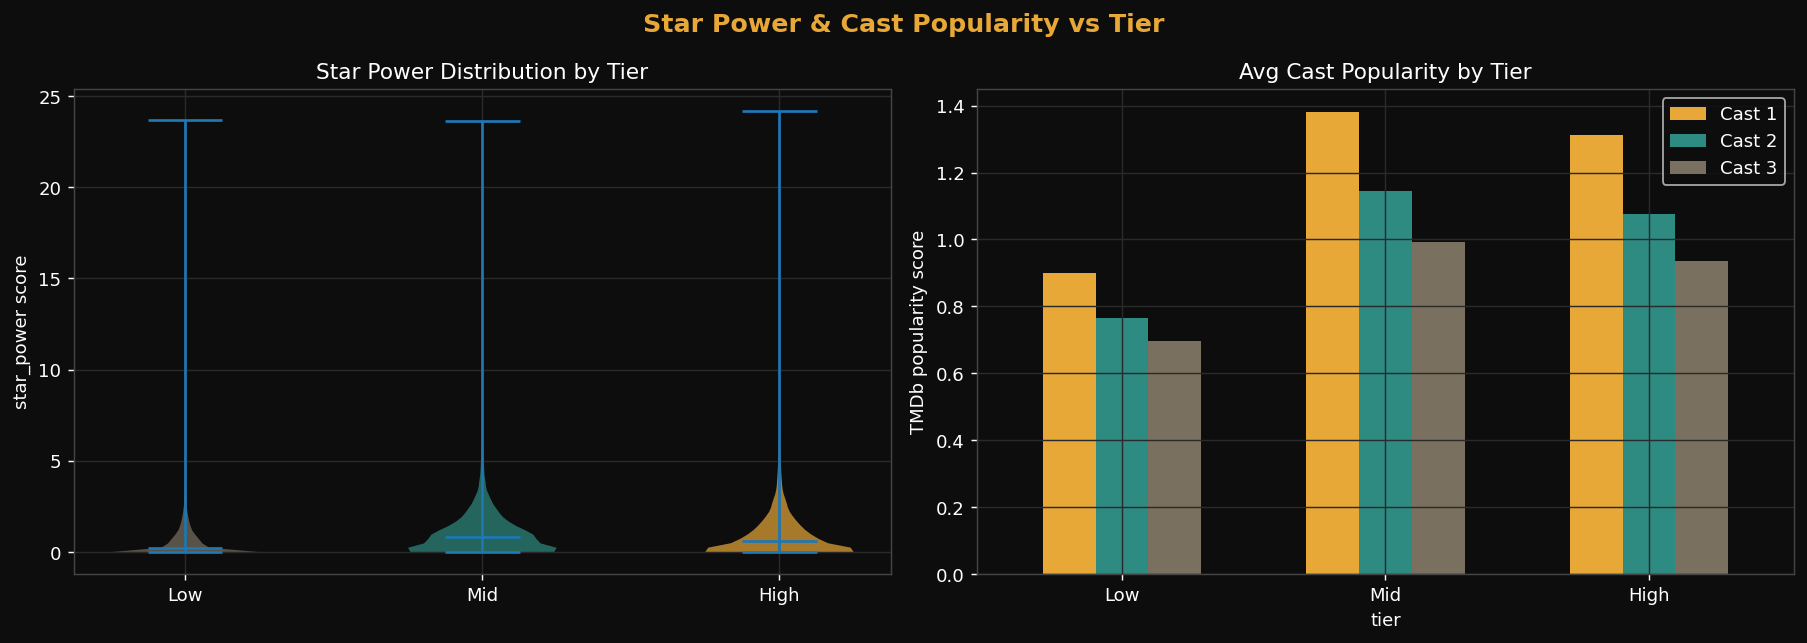

In [22]:
# Star power vs tier
star_df = films.dropna(subset=["star_power","tier"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Star Power & Cast Popularity vs Tier", color=GOLD, fontsize=14, fontweight="bold")

# Star power violin
sp_data = [star_df[star_df["tier"]==t]["star_power"] for t in ["Low","Mid","High"]]
vp = axes[0].violinplot(sp_data, positions=[0,1,2], showmedians=True)
for body,color in zip(vp["bodies"],[MUTED,TEAL,GOLD]):
    body.set_facecolor(color); body.set_alpha(0.7)
axes[0].set_xticks([0,1,2]); axes[0].set_xticklabels(["Low","Mid","High"])
axes[0].set_title("Star Power Distribution by Tier")
axes[0].set_ylabel("star_power score")

# Cast popularity stacked bar
cast_means = films.groupby("tier")[["cast_1_popularity","cast_2_popularity","cast_3_popularity"]].mean().reindex(["Low","Mid","High"])
cast_means.plot(kind="bar", ax=axes[1], color=[GOLD, TEAL, MUTED], width=0.6)
axes[1].set_title("Avg Cast Popularity by Tier")
axes[1].set_ylabel("TMDb popularity score")
axes[1].set_xticklabels(["Low","Mid","High"], rotation=0)
axes[1].legend(["Cast 1","Cast 2","Cast 3"])

plt.tight_layout()
plt.savefig("star_power.png", bbox_inches="tight", facecolor="#0d0d0d")
plt.show()

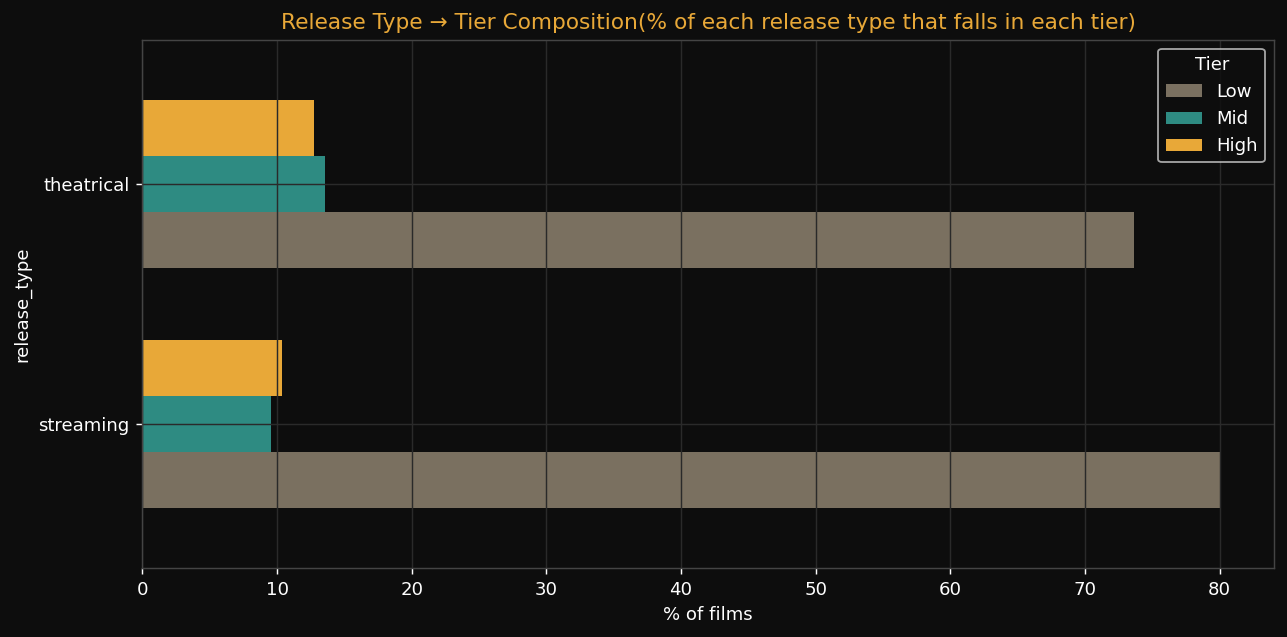

tier          High   Low   Mid
release_type                  
streaming     10.4  80.0   9.6
theatrical    12.8  73.6  13.6


In [24]:
# Release type breakdown by tier — ML pointing analysis
rel_df = films.dropna(subset=["release_type","tier"])
rel_ct = pd.crosstab(rel_df["release_type"], rel_df["tier"], normalize="index") * 100

fig, ax = plt.subplots(figsize=(10, 5))
rel_ct[["Low","Mid","High"]].plot(kind="barh", ax=ax, color=[MUTED, TEAL, GOLD], width=0.7)
ax.set_title("Release Type → Tier Composition(% of each release type that falls in each tier)",
             color=GOLD, fontsize=12)
ax.set_xlabel("% of films")
ax.legend(title="Tier")
plt.tight_layout()
plt.savefig("release_type_tier.png", bbox_inches="tight", facecolor="#0d0d0d")
plt.show()
print(rel_ct.round(1))

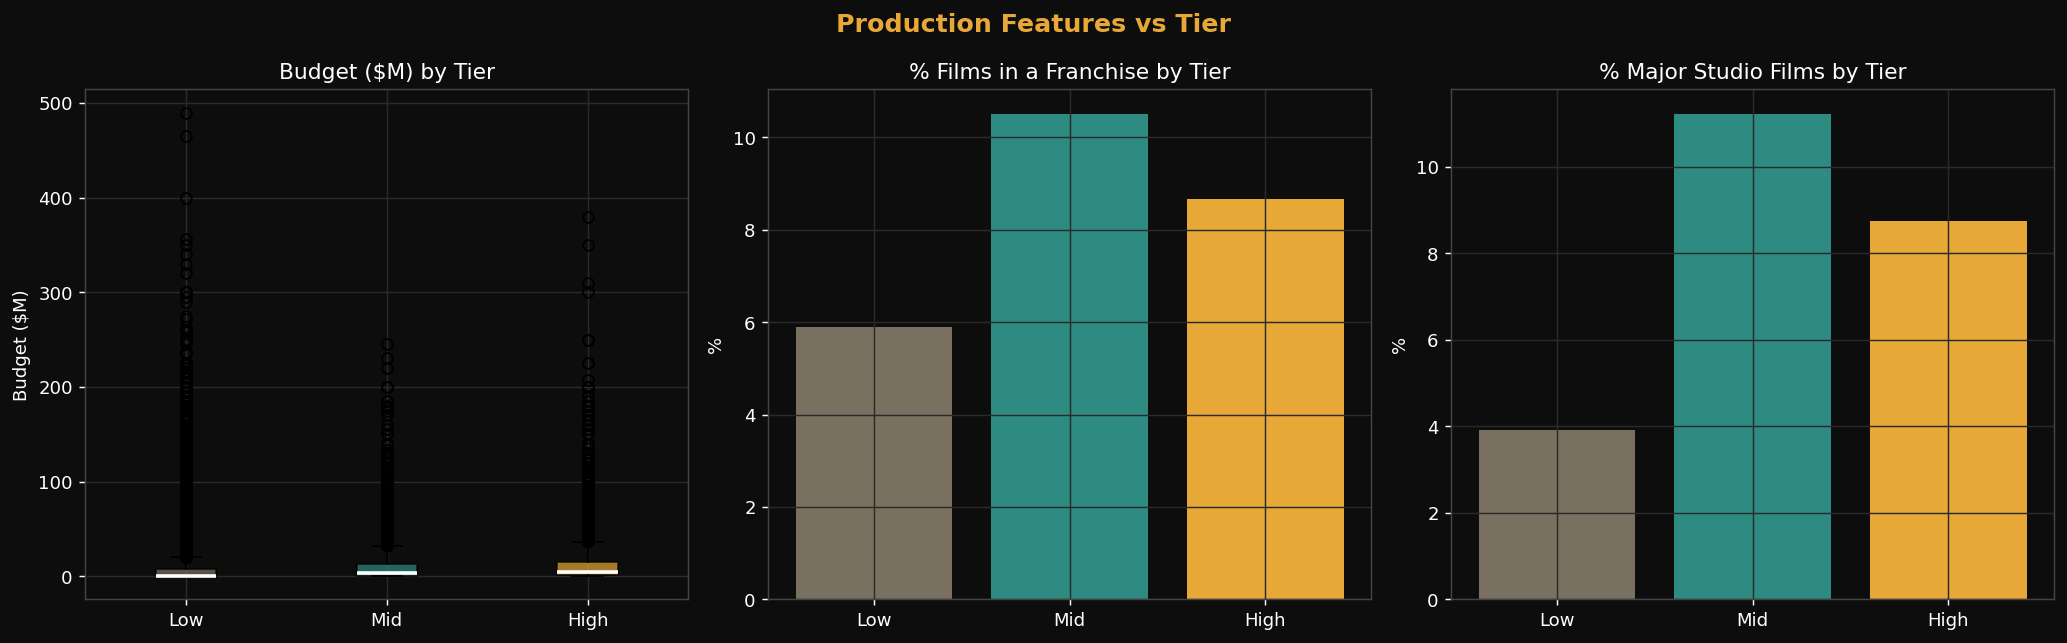

In [25]:
# Budget, franchise, keyword flags vs tier
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Production Features vs Tier", color=GOLD, fontsize=14, fontweight="bold")

# Budget
bud_df = films.dropna(subset=["budget_x","tier"])
bud_data = [bud_df[bud_df["tier"]==t]["budget_x"]/1e6 for t in ["Low","Mid","High"]]
bp = axes[0].boxplot(bud_data, labels=["Low","Mid","High"], patch_artist=True,
                     medianprops=dict(color="white",linewidth=2))
for patch,color in zip(bp["boxes"],[MUTED,TEAL,GOLD]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[0].set_title("Budget ($M) by Tier"); axes[0].set_ylabel("Budget ($M)")

# Franchise flag
if "in_franchise_x" in films.columns:
    fr = films.dropna(subset=["in_franchise_x","tier"])
    fr_rate = fr.groupby("tier")["in_franchise_x"].apply(lambda x: x.astype(bool).mean()*100).reindex(["Low","Mid","High"])
    axes[1].bar(["Low","Mid","High"], fr_rate, color=[MUTED,TEAL,GOLD])
    axes[1].set_title("% Films in a Franchise by Tier"); axes[1].set_ylabel("%")

# Major studio flag
if "is_major_studio" in films.columns:
    ms = films.dropna(subset=["is_major_studio","tier"])
    ms["is_major_studio"] = ms["is_major_studio"].astype(str).str.lower().map({"true":True,"false":False})
    ms_rate = ms.groupby("tier")["is_major_studio"].apply(lambda x: x.mean()*100).reindex(["Low","Mid","High"])
    axes[2].bar(["Low","Mid","High"], ms_rate, color=[MUTED,TEAL,GOLD])
    axes[2].set_title("% Major Studio Films by Tier"); axes[2].set_ylabel("%")

plt.tight_layout()
plt.savefig("production_features.png", bbox_inches="tight", facecolor="#0d0d0d")
plt.show()

## 4  Feature Correlations (ML Setup)

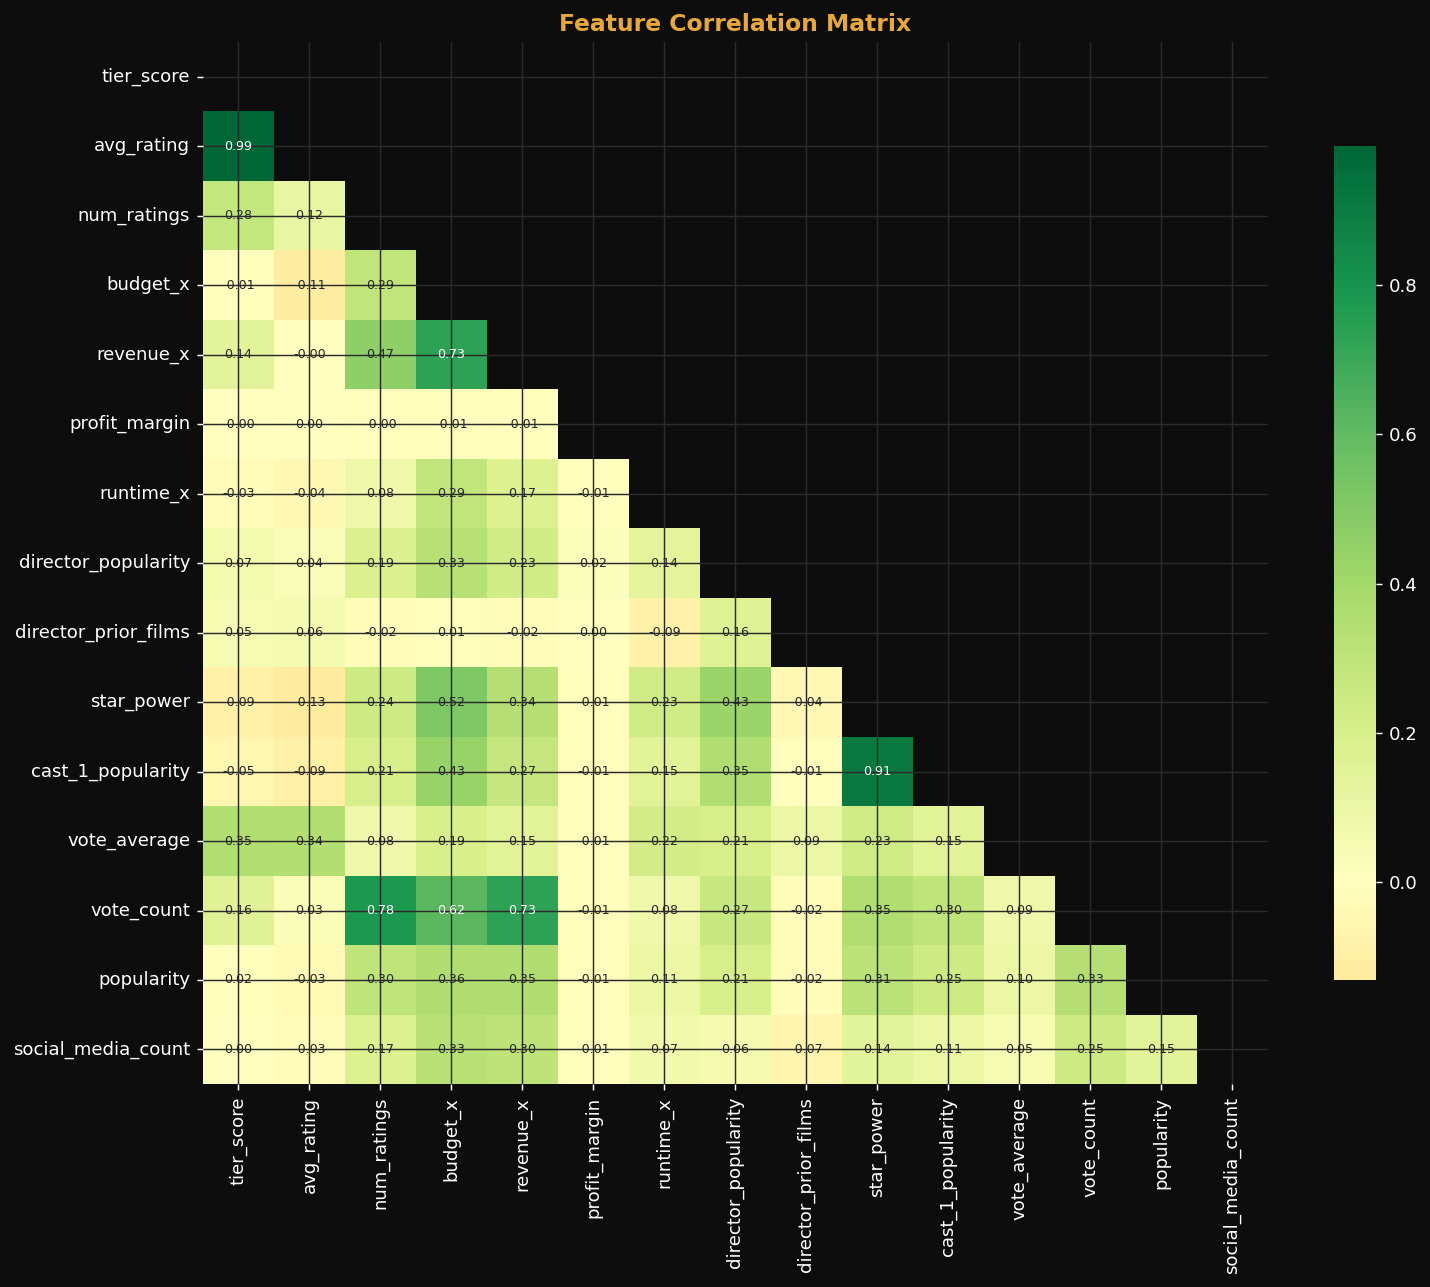

In [26]:
# Numeric correlation heatmap — what predicts tier_score?
numeric_cols = [
    "tier_score","avg_rating","num_ratings","budget_x","revenue_x",
    "profit_margin","runtime_x","director_popularity","director_prior_films",
    "star_power","cast_1_popularity","vote_average","vote_count",
    "popularity","social_media_count","cast_size","keyword_count",
]
numeric_cols = [c for c in numeric_cols if c in films.columns]
corr = films[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, ax=ax, annot_kws={"size":7},
            cbar_kws={"shrink":0.8})
ax.set_title("Feature Correlation Matrix", color=GOLD, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", bbox_inches="tight", facecolor="#0d0d0d")
plt.show()

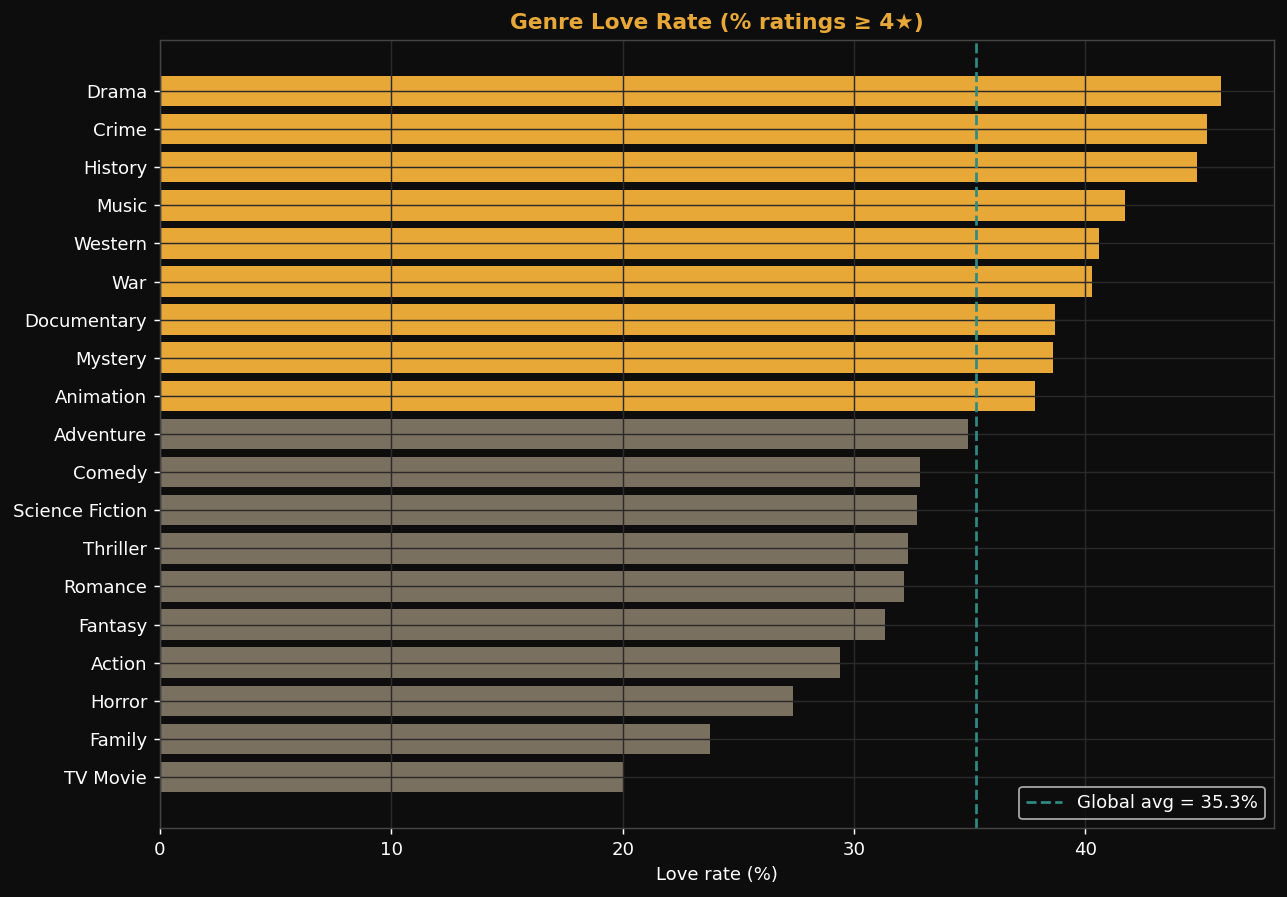

          genre  love_rate_pct
          Drama      45.854123
          Crime      45.235185
        History      44.837176
          Music      41.717341
        Western      40.579627
            War      40.278956
    Documentary      38.699543
        Mystery      38.602755
      Animation      37.808948
      Adventure      34.906805
         Comedy      32.866741
Science Fiction      32.710777
       Thriller      32.345167
        Romance      32.140219
        Fantasy      31.334167
         Action      29.377246
         Horror      27.350120
         Family      23.758443
       TV Movie      20.016237


In [27]:
# Genre love rate (Letterboxd) — used in classification model
love_threshold = 4.0
genre_love = (
    df.dropna(subset=["rating","genre"])
    .groupby("genre")
    .apply(lambda g: (g["rating"] >= love_threshold).mean() * 100)
    .reset_index(name="love_rate_pct")
    .sort_values("love_rate_pct", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 7))
colors_lr = [GOLD if r >= genre_love["love_rate_pct"].mean() else MUTED
             for r in genre_love["love_rate_pct"]]
ax.barh(genre_love["genre"], genre_love["love_rate_pct"], color=colors_lr)
ax.axvline(genre_love["love_rate_pct"].mean(), color=TEAL, linestyle="--", linewidth=1.5,
           label=f"Global avg = {genre_love['love_rate_pct'].mean():.1f}%")
ax.set_title("Genre Love Rate (% ratings ≥ 4★)", color=GOLD, fontsize=12, fontweight="bold")
ax.set_xlabel("Love rate (%)")
ax.legend()
plt.tight_layout()
plt.savefig("genre_love_rate.png", bbox_inches="tight", facecolor="#0d0d0d")
plt.show()
print(genre_love.sort_values("love_rate_pct", ascending=False).to_string(index=False))

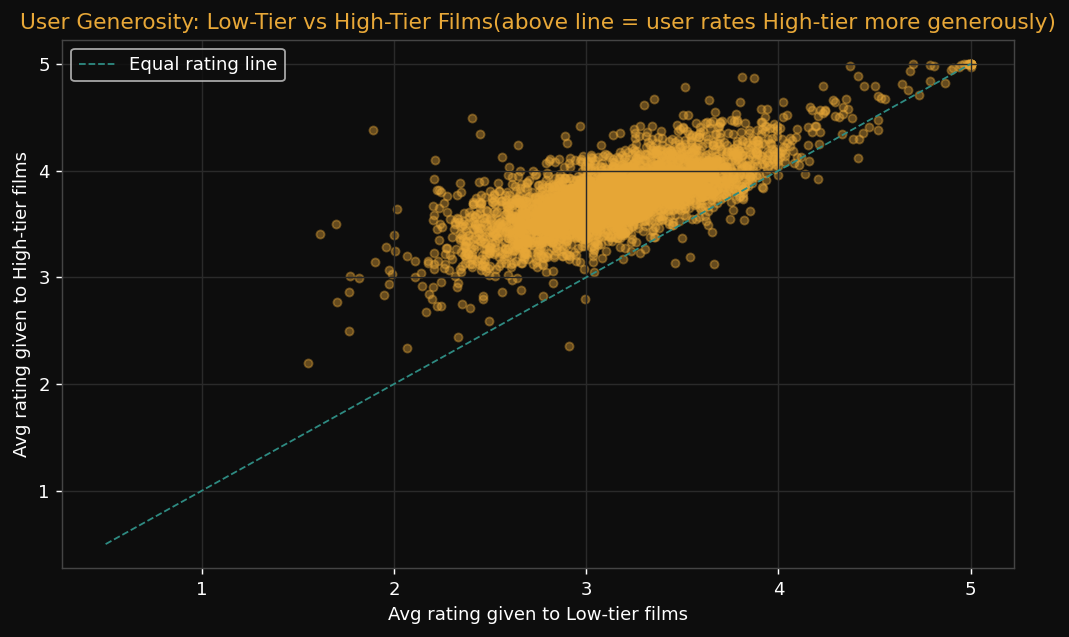

In [29]:
# Do users rate high-tier films more generously than they deserve?
user_tier = df.dropna(subset=["rating","tier"]).groupby(["username","tier"])["rating"].mean().reset_index()
user_wide = user_tier.pivot(index="username", columns="tier", values="rating").dropna()

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(user_wide.get("Low", pd.Series()), user_wide.get("High", pd.Series()),
           alpha=0.4, color=GOLD, s=20)
ax.plot([0.5, 5], [0.5, 5], color=TEAL, linestyle="--", linewidth=1, label="Equal rating line")
ax.set_xlabel("Avg rating given to Low-tier films")
ax.set_ylabel("Avg rating given to High-tier films")
ax.set_title("User Generosity: Low-Tier vs High-Tier Films(above line = user rates High-tier more generously)",
             color=GOLD)
ax.legend()
plt.tight_layout()
plt.savefig("user_generosity.png", bbox_inches="tight", facecolor="#0d0d0d")
plt.show()

## 5  Recommender Patterns (Jaccard · Tastemates · Pairs)

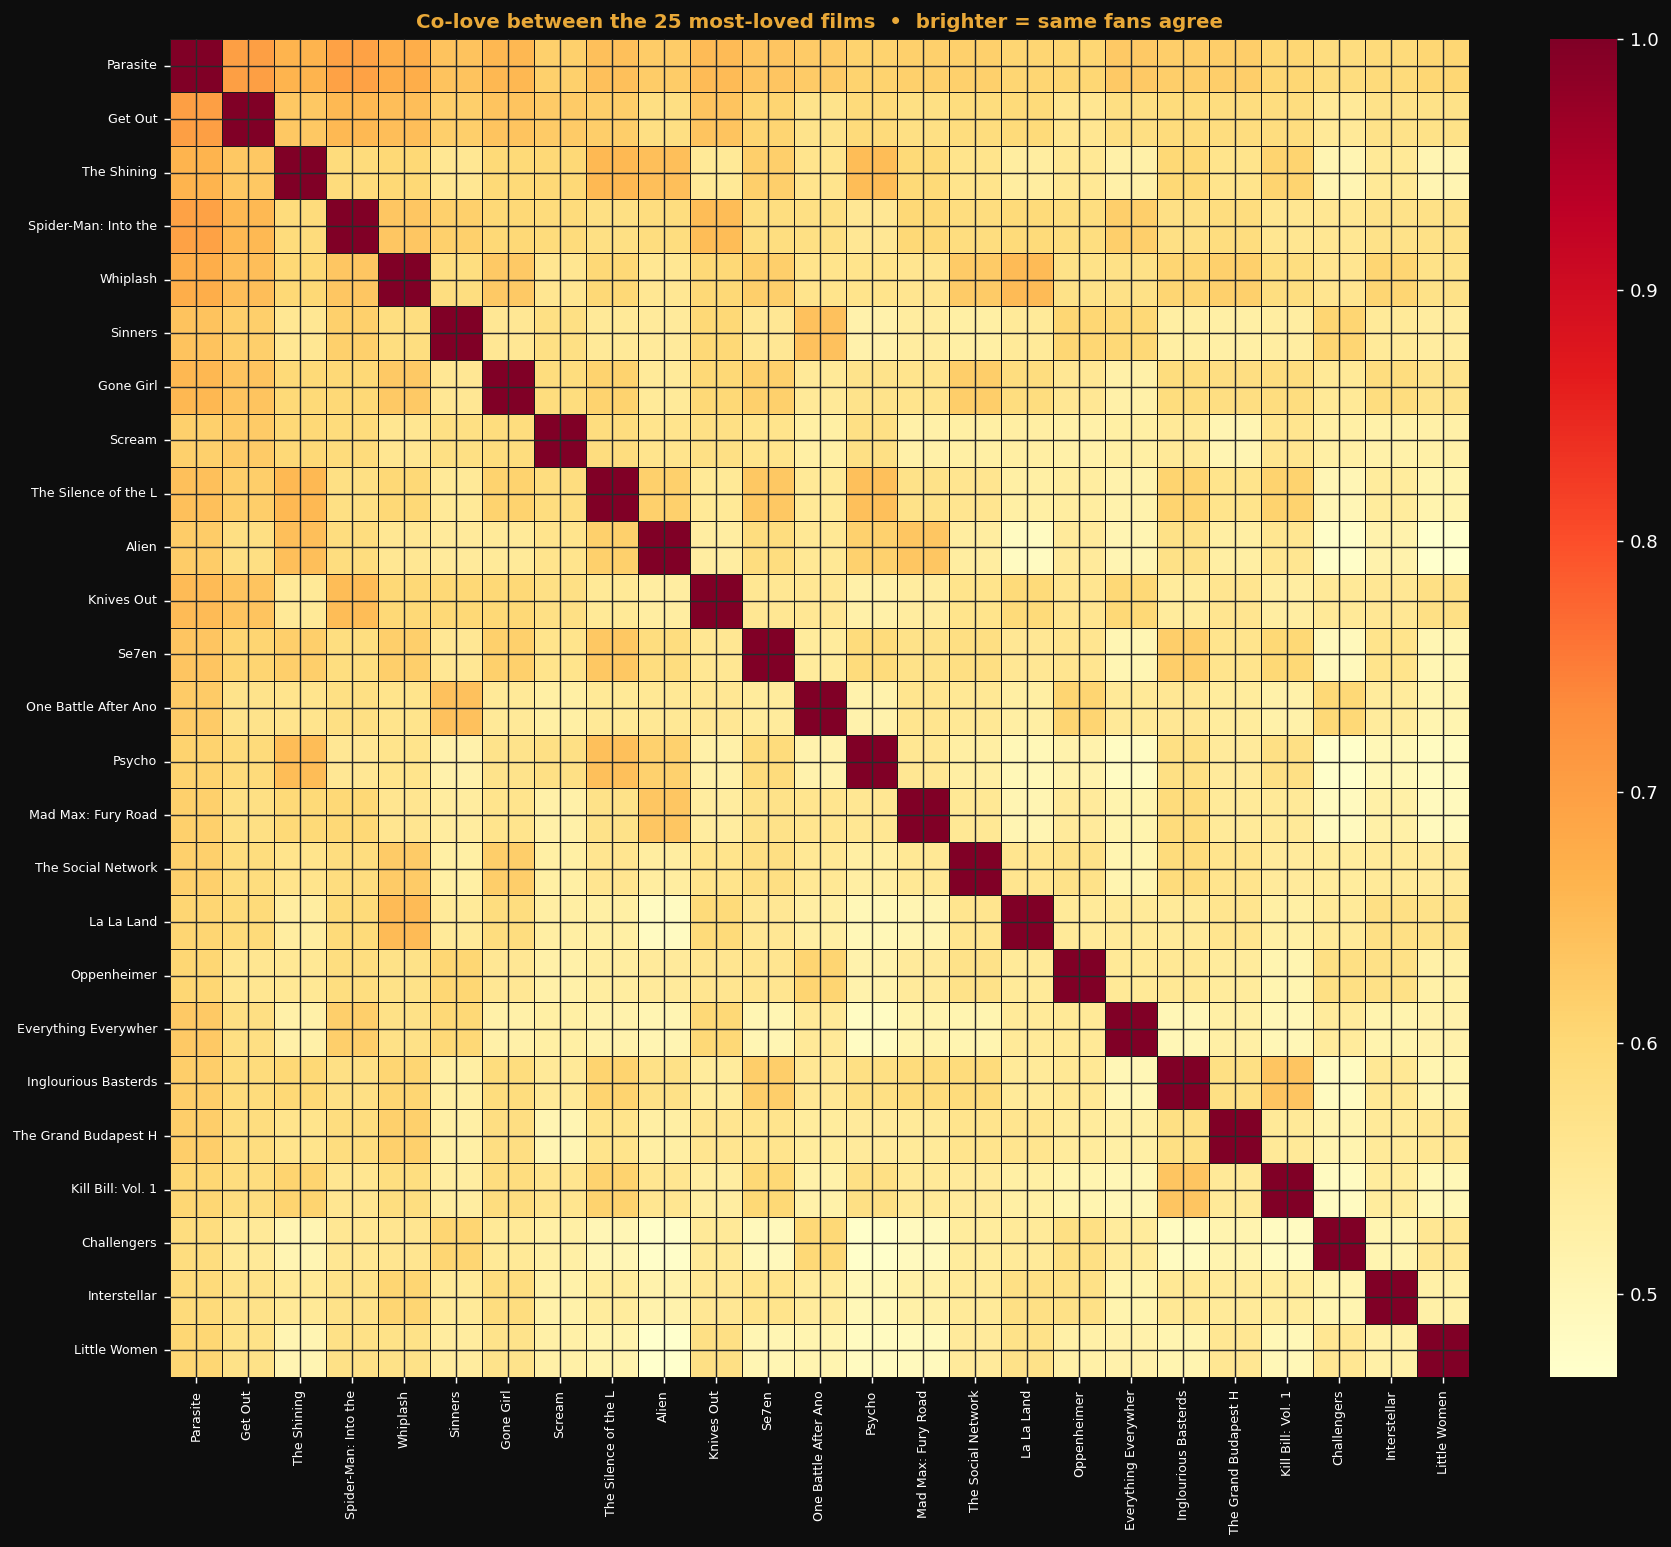

: 

In [ ]:
# ── Jaccard co-love heatmap ───────────────────────────────────────────────────
LOVE_THRESH = 4.0
MIN_LOVERS  = 80   # min users who loved a film to include in heatmap

loved = df[df["rating"] >= LOVE_THRESH].copy()
film_love_counts = loved.groupby("movie_title")["username"].nunique()
eligible = film_love_counts[film_love_counts >= MIN_LOVERS].index.tolist()

# limit to top 25 most-loved for readability
top_films = film_love_counts[eligible].nlargest(25).index.tolist()

user_sets = {
    film: set(loved[loved["movie_title"] == film]["username"])
    for film in top_films
}

def jaccard(a, b):
    if not a or not b: return 0
    return len(a & b) / len(a | b)

jac_matrix = pd.DataFrame(index=top_films, columns=top_films, dtype=float)
for f1 in top_films:
    for f2 in top_films:
        jac_matrix.loc[f1, f2] = jaccard(user_sets[f1], user_sets[f2])

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(jac_matrix.astype(float), cmap="YlOrRd", ax=ax,
            xticklabels=[f[:20] for f in top_films],
            yticklabels=[f[:20] for f in top_films],
            linewidths=0.3, linecolor="#1a1a1a")
ax.set_title("Co-love between the 25 most-loved films  •  brighter = same fans agree",
             color=GOLD, fontsize=11, fontweight="bold")
ax.tick_params(axis="x", rotation=90, labelsize=7)
ax.tick_params(axis="y", rotation=0,  labelsize=7)
plt.tight_layout()
plt.savefig("jaccard_heatmap.png", bbox_inches="tight", facecolor="#0d0d0d")
plt.show()

In [ ]:
# ── Tastemate finder (cosine similarity on user-film rating matrix) ──────────
from sklearn.metrics.pairwise import cosine_similarity

# pivot: users × films, mean-centered
pivot = (
    df.dropna(subset=["rating"])
    .groupby(["username","movie_title"])["rating"]
    .mean()
    .unstack(fill_value=0)
)
# subtract user mean
pivot_centered = pivot.sub(pivot.mean(axis=1), axis=0)

cos_sim = cosine_similarity(pivot_centered)
sim_df = pd.DataFrame(cos_sim, index=pivot.index, columns=pivot.index)

def get_tastemates(username, n=5):
    if username not in sim_df.index:
        return []
    row = sim_df.loc[username].drop(username)
    return row.nlargest(n).index.tolist()

# show for 3 sample users
sample_users = pivot.index[:3].tolist()
fig, axes = plt.subplots(1, len(sample_users), figsize=(18, 6))
fig.suptitle("Tastemate Finder  •  top 5 nearest tastemates × shared loves",
             color=GOLD, fontsize=12, fontweight="bold")

for ax, user in zip(axes, sample_users):
    mates = get_tastemates(user, 5)
    shared = loved[loved["username"].isin([user]+mates)]
    shared_counts = shared.groupby("movie_title")["username"].nunique()
    top_shared = shared_counts[shared_counts == len([user]+mates)].nlargest(12)
    if top_shared.empty:
        top_shared = shared_counts.nlargest(12)
    ax.barh(top_shared.index[::-1], top_shared.values[::-1], color=TEAL)
    ax.set_title(f"@{user}\nmates: {', '.join(['@'+m for m in mates[:2]])}..",
                 color=GOLD, fontsize=8)
    ax.set_xlabel("# tastemates who love it")
    ax.tick_params(axis="y", labelsize=7)

plt.tight_layout()
plt.savefig("tastemate_finder.png", bbox_inches="tight", facecolor="#0d0d0d")
plt.show()

In [ ]:
# ── Pair recommender ─────────────────────────────────────────────────────────
def pair_recommend(user1, user2, top_n=10):
    if user1 not in sim_df.index or user2 not in sim_df.index:
        return pd.Series(dtype=float)
    cos = sim_df.loc[user1, user2]
    # find cohort: users similar to both
    avg_sim = (sim_df.loc[user1] + sim_df.loc[user2]) / 2
    cohort = avg_sim.drop([user1, user2]).nlargest(12).index.tolist()
    seen = set(df[df["username"].isin([user1,user2])]["movie_title"])
    cohort_loved = loved[loved["username"].isin(cohort) & ~loved["movie_title"].isin(seen)]
    recs = cohort_loved.groupby("movie_title")["username"].nunique().nlargest(top_n)
    return recs, cos

sample_pairs = list(combinations(sample_users, 2))[:3]
fig, axes = plt.subplots(1, len(sample_pairs), figsize=(18, 6))
if len(sample_pairs)==1: axes=[axes]
fig.suptitle("Pair Recommender  •  what the cohort agrees on (and the pair hasn't seen)",
             color=GOLD, fontsize=11, fontweight="bold")

for ax, (u1, u2) in zip(axes, sample_pairs):
    try:
        recs, cos = pair_recommend(u1, u2)
        ax.barh(recs.index[::-1], recs.values[::-1], color=TEAL)
        ax.set_title(f"@{u1} × @{u2}\ncosine={cos:.3f}", color=GOLD, fontsize=8)
        ax.set_xlabel("# cohort who love it")
        ax.tick_params(axis="y", labelsize=7)
    except Exception as e:
        ax.text(0.5,0.5,str(e),transform=ax.transAxes,ha="center",color="white")

plt.tight_layout()
plt.savefig("pair_recommender.png", bbox_inches="tight", facecolor="#0d0d0d")
plt.show()

In [ ]:
# ── Genre co-love intersections (Pearson across users) ───────────────────────
all_genres = [g for g in df["genre"].dropna().unique()]

genre_user_love = {}
for g in all_genres:
    genre_films = df[df["genre"]==g]["movie_title"].unique()
    lovers = set(loved[loved["movie_title"].isin(genre_films)]["username"])
    genre_user_love[g] = lovers

all_users = set(df["username"].unique())
genre_vectors = pd.DataFrame(
    {g: pd.Series({u: 1 if u in genre_user_love[g] else 0 for u in all_users})
     for g in all_genres}
)
genre_corr = genre_vectors.corr()

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(genre_corr, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, ax=ax, annot_kws={"size":7},
            xticklabels=True, yticklabels=True)
ax.set_title("Genre Co-love  •  do their lovers overlap heavily?",
             color=GOLD, fontsize=12, fontweight="bold")
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", rotation=0, labelsize=8)
plt.tight_layout()
plt.savefig("genre_intersections.png", bbox_inches="tight", facecolor="#0d0d0d")
plt.show()

In [ ]:
# ── Most-loved films + love conversion rate ───────────────────────────────────
film_stats = (
    df.dropna(subset=["rating"])
    .groupby("movie_title")
    .agg(
        total_raters=("username","nunique"),
        lovers=("rating", lambda x: (x >= LOVE_THRESH).sum()),
        avg_r=("rating","mean"),
    )
    .assign(love_conv=lambda d: d["lovers"]/d["total_raters"]*100)
    .query("total_raters >= 50")
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Most-Loved Films", color=GOLD, fontsize=13, fontweight="bold")

# raw loves
top_loved = film_stats.nlargest(12,"lovers")
axes[0].barh(top_loved.index[::-1], top_loved["lovers"][::-1], color=GOLD)
axes[0].set_title("Most-loved films (raw count)")
axes[0].set_xlabel("# users who loved it")
for i,(idx,row) in enumerate(top_loved[::-1].iterrows()):
    axes[0].text(row["lovers"]+1, i, f"{int(row['lovers'])} loves  •  {row['love_conv']:.0f}% conv.",
                 va="center", color="white", fontsize=7)

# conversion rate
top_conv = film_stats.query("total_raters >= 80").nlargest(12,"love_conv")
axes[1].barh(top_conv.index[::-1], top_conv["love_conv"][::-1], color=TEAL)
axes[1].set_title(f"Highest love-conversion films (≥ 80 viewers)")
axes[1].set_xlabel("Love conversion (loved / seen, %)")
for i,(idx,row) in enumerate(top_conv[::-1].iterrows()):
    axes[1].text(row["love_conv"]+0.3, i,
                 f"{int(row['lovers'])}/{int(row['total_raters'])}",
                 va="center", color="white", fontsize=7)

plt.tight_layout()
plt.savefig("most_loved_films.png", bbox_inches="tight", facecolor="#0d0d0d")
plt.show()

In [ ]:
# ── User genre fingerprints (radar) ─────────────────────────────────────────
genres_radar = [g for g in df["genre"].dropna().unique() if df[df["genre"]==g]["username"].nunique() > 5][:12]
sample_fp_users = pivot.index[:4].tolist()

fig, axes = plt.subplots(1, len(sample_fp_users), figsize=(20, 5), subplot_kw=dict(polar=True))
fig.suptitle("Four user genre fingerprints — same axes, very different shapes",
             color=GOLD, fontsize=11, fontweight="bold")

angles = np.linspace(0, 2*np.pi, len(genres_radar), endpoint=False).tolist()
angles += angles[:1]

for ax, user in zip(axes, sample_fp_users):
    user_data = df[df["username"]==user]
    values = []
    for g in genres_radar:
        g_data = user_data[user_data["genre"]==g]["rating"].dropna()
        values.append(g_data.mean() if len(g_data) else 0)
    values += values[:1]
    loved_genre = (
        user_data[user_data["rating"]>=LOVE_THRESH]
        .groupby("genre").size().idxmax()
        if len(user_data[user_data["rating"]>=LOVE_THRESH]) > 0 else "?"
    )
    love_pct = (user_data["rating"] >= LOVE_THRESH).mean() * 100

    ax.plot(angles, values, color=GOLD, linewidth=1.5)
    ax.fill(angles, values, alpha=0.25, color=GOLD)

    # highlight top genre
    top_idx = np.argmax(values[:-1])
    ax.plot([angles[top_idx]], [values[top_idx]], "o", color=TEAL, markersize=8)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([g[:8] for g in genres_radar], size=6, color="white")
    ax.set_yticklabels([]); ax.set_ylim(0,5)
    ax.set_facecolor("#0d0d0d")
    ax.spines["polar"].set_color("#444")
    ax.set_title(f"@{user}\n★ {loved_genre} super-fan ({love_pct:.0f}% loves)",
                 color=GOLD, fontsize=8, pad=10)

plt.tight_layout()
plt.savefig("user_fingerprints.png", bbox_inches="tight", facecolor="#0d0d0d")
plt.show()

## 6  Export

In [ ]:
# ── Save film-level enriched table for ML ────────────────────────────────────
# Add genre love rate
genre_love_map = genre_love.set_index("genre")["love_rate_pct"].to_dict()
films["genre_love_rate"] = films["genre"].map(genre_love_map)

out_path = REPO / "film_enriched_eda.csv"
films.to_csv(out_path, index=False)
print(f"Saved {len(films):,} films → {out_path}")
print(films.columns.tolist())